# Embedding-Based Variety Comparison
Baseline exact-signature variety vs. embedding-cluster variety, evaluated on
a latent-concept synthetic stream. Shows the treatment recovers more distinct
concepts at a fixed keep budget, unifies synonym vocab, and flags novelty.

## 1. The problem with exact-match variety
Exact tool-signature matching (a) over-counts trivially different signatures as
distinct, (b) has no notion of *novelty vs. seen-before* beyond first sight, and
(c) treats synonym vocab (`search` vs `query`) as unrelated. Embeddings fix all
three by clustering semantically similar tool sequences.

In [1]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from trace_sampling.concepts import ConceptSpec, SynonymMap
from trace_sampling.generator import generate_concept_stream, ConceptAgentConfig

sm = SynonymMap([['search','query','find'],['edit','modify'],['run','exec'],
                 ['deploy','release']])
concepts = [ConceptSpec(0,('search','edit')), ConceptSpec(1,('run','search')),
            ConceptSpec(2,('deploy',)), ConceptSpec(3,('edit','run','search'))]
agents = [
  ConceptAgentConfig('agent_a', 12.0, (0,1,2,3), zipf_s=1.2,
     vocab_bias={'search':'search','edit':'edit','run':'run','deploy':'deploy'}),
  ConceptAgentConfig('agent_b', 40.0, (0,1), zipf_s=0.6,
     vocab_bias={'search':'query','edit':'modify','run':'exec','deploy':'release'}),
  ConceptAgentConfig('agent_c', 3.0, (2,3), zipf_s=1.0,
     vocab_bias={'search':'find','edit':'edit','run':'run','deploy':'release'}),
]
stream = generate_concept_stream(agents, concepts, sm, duration=120.0, seed=7)
print('traces:', len(stream))
same = {(t.agent_id, t.signature) for t in stream if t.concept_id==0}
pd.Series([str(s) for s in sorted({str(x) for x in same})]).head(10)

traces: 6688


0                        ('agent_a', ('edit', 'edit'))
1                               ('agent_a', ('edit',))
2                      ('agent_a', ('search', 'edit'))
3              ('agent_a', ('search', 'edit', 'edit'))
4                    ('agent_a', ('search', 'search'))
5            ('agent_a', ('search', 'search', 'edit'))
6    ('agent_a', ('search', 'search', 'edit', 'edit'))
7                             ('agent_a', ('search',))
8                    ('agent_b', ('modify', 'modify'))
9                             ('agent_b', ('modify',))
dtype: str

In [2]:
import os
from trace_sampling.samplers import SamplerConfig
from trace_sampling.eval_harness import run_arm, kept_embeddings

cfg = SamplerConfig(llm_throughput=8.0)
AZURE = os.environ.get('RUN_AZURE_TESTS') == '1'
treatment_arm = 'treatment_azure' if AZURE else 'treatment_offline'
if not AZURE:
    print('WARNING: RUN_AZURE_TESTS!=1 -> using deterministic offline treatment.')
base = run_arm(stream, cfg, arm='baseline', seed=0)
treat = run_arm(stream, cfg, arm=treatment_arm, seed=0, synonym_map=sm)
print('baseline ledger:', base.ledger)
print('treatment ledger:', treat.ledger)

baseline ledger: {'embed_calls': 0, 'cache_hits': 0, 'cache_hit_rate': 0.0, 'search_queries': 0, 'embed_latency_p50_ms': 0.0, 'embed_latency_p95_ms': 0.0, 'added_latency_p50_ms': 0.007500406354665756, 'added_latency_p95_ms': 0.00929972156882286, 'est_cost_usd': 0.0, 'fallbacks': 0, 'kept': 164}
treatment ledger: {'embed_calls': 57, 'cache_hits': 6631, 'cache_hit_rate': 0.9914772727272727, 'search_queries': 21, 'embed_latency_p50_ms': 0.15960028395056725, 'embed_latency_p95_ms': 0.30178008601069445, 'added_latency_p50_ms': 0.0412999652326107, 'added_latency_p95_ms': 0.076299998909235, 'est_cost_usd': 1.1400000000000001e-05, 'fallbacks': 0, 'kept': 139}


In [3]:
from trace_sampling.variety_metrics import (concept_coverage,
    redundancy_per_concept, cluster_agreement, novel_concept_latency,
    novel_concept_latency_traces, cross_agent_unification)

cov_b = concept_coverage(base.log); cov_t = concept_coverage(treat.log)
ari_b, v_b = cluster_agreement(base.log); ari_t, v_t = cluster_agreement(treat.log)
red_b = redundancy_per_concept(base.log); red_t = redundancy_per_concept(treat.log)
import numpy as np
med_red_b = float(np.median(list(red_b.values()))) if red_b else 0.0
med_red_t = float(np.median(list(red_t.values()))) if red_t else 0.0
print(dict(cov_b=cov_b, cov_t=cov_t, ari_b=ari_b, ari_t=ari_t,
           med_red_b=med_red_b, med_red_t=med_red_t))

{'cov_b': 1.0, 'cov_t': 1.0, 'ari_b': 0.24620603556000623, 'ari_t': 0.4078209600613503, 'med_red_b': 47.0, 'med_red_t': 37.0}


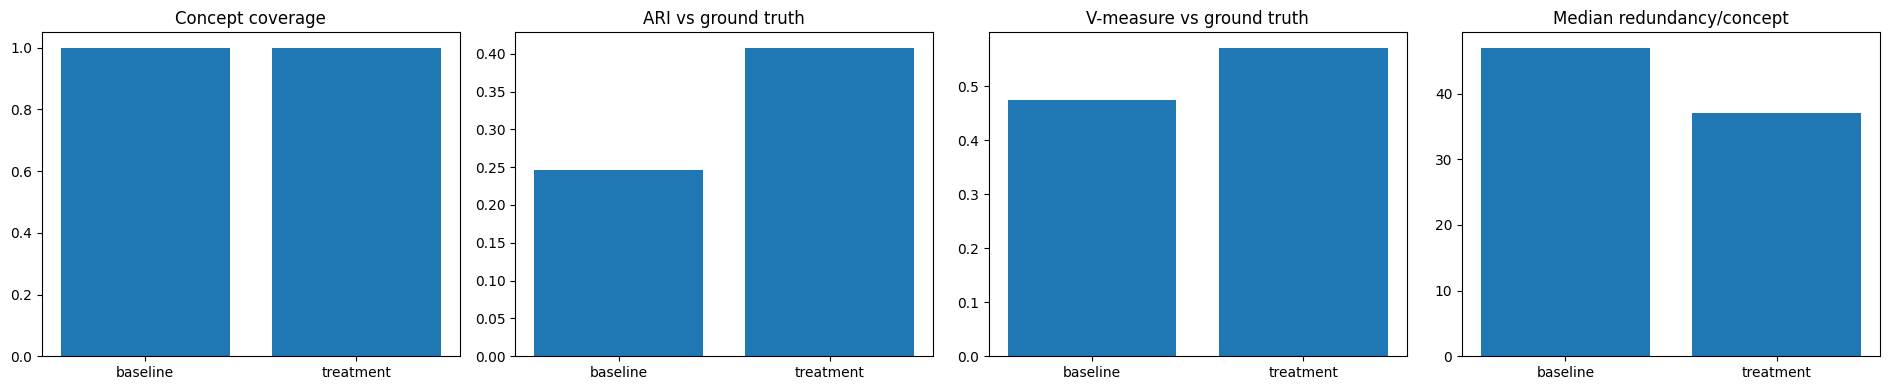

In [4]:
fig, ax = plt.subplots(1, 4, figsize=(19, 4))
ax[0].bar(['baseline','treatment'], [cov_b, cov_t]); ax[0].set_title('Concept coverage')
ax[1].bar(['baseline','treatment'], [ari_b, ari_t]); ax[1].set_title('ARI vs ground truth')
ax[2].bar(['baseline','treatment'], [v_b, v_t]); ax[2].set_title('V-measure vs ground truth')
ax[3].bar(['baseline','treatment'], [med_red_b, med_red_t]); ax[3].set_title('Median redundancy/concept')
plt.tight_layout(); plt.show()

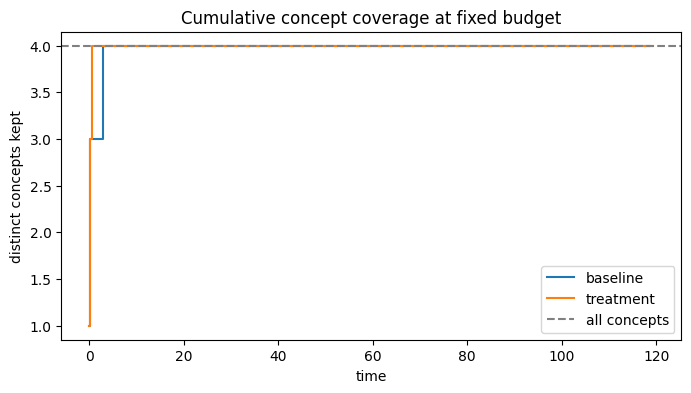

In [5]:
def coverage_curve(log):
    kept = log[log['kept']].sort_values('timestamp')
    seen = set(); xs = []; ys = []
    for _, r in kept.iterrows():
        seen.add(r['concept_id']); xs.append(r['timestamp']); ys.append(len(seen))
    return xs, ys
xb, yb = coverage_curve(base.log); xt, yt = coverage_curve(treat.log)
n_concepts = base.log['concept_id'].nunique()
plt.figure(figsize=(8,4))
plt.step(xb, yb, where='post', label='baseline')
plt.step(xt, yt, where='post', label='treatment')
plt.axhline(n_concepts, ls='--', c='grey', label='all concepts')
plt.xlabel('time'); plt.ylabel('distinct concepts kept')
plt.title('Cumulative concept coverage at fixed budget'); plt.legend(); plt.show()

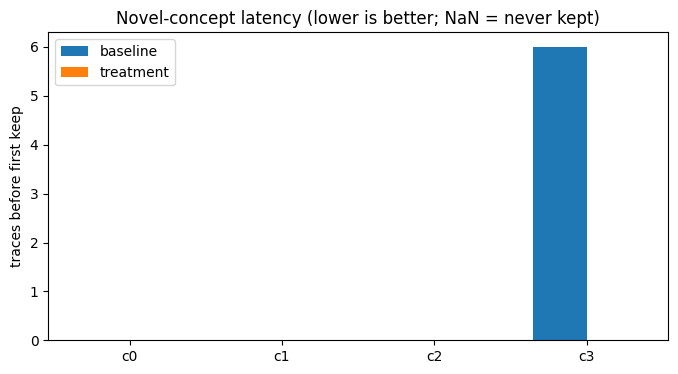

In [6]:
lat_b = novel_concept_latency_traces(base.log)
lat_t = novel_concept_latency_traces(treat.log)
cids = sorted(set(lat_b) | set(lat_t))
def _finite(d, k): 
    v = d.get(k, float('inf')); return v if np.isfinite(v) else np.nan
xb = [_finite(lat_b, c) for c in cids]; xt = [_finite(lat_t, c) for c in cids]
x = np.arange(len(cids)); w = 0.35
plt.figure(figsize=(8,4))
plt.bar(x - w/2, xb, w, label='baseline')
plt.bar(x + w/2, xt, w, label='treatment')
plt.xticks(x, [f'c{c}' for c in cids]); plt.ylabel('traces before first keep')
plt.title('Novel-concept latency (lower is better; NaN = never kept)')
plt.legend(); plt.show()

,embed_calls,cache_hits,cache_hit_rate,search_queries,embed_latency_p50_ms,embed_latency_p95_ms,added_latency_p50_ms,added_latency_p95_ms,est_cost_usd,fallbacks,kept
arm,,,,,,,,,,,
baseline,0,0,0.000000,0,0.0000,0.00000,0.0075,0.0093,0.000000,0,164
treatment,57,6631,0.991477,21,0.1596,0.30178,0.0413,0.0763,0.000011,0,139


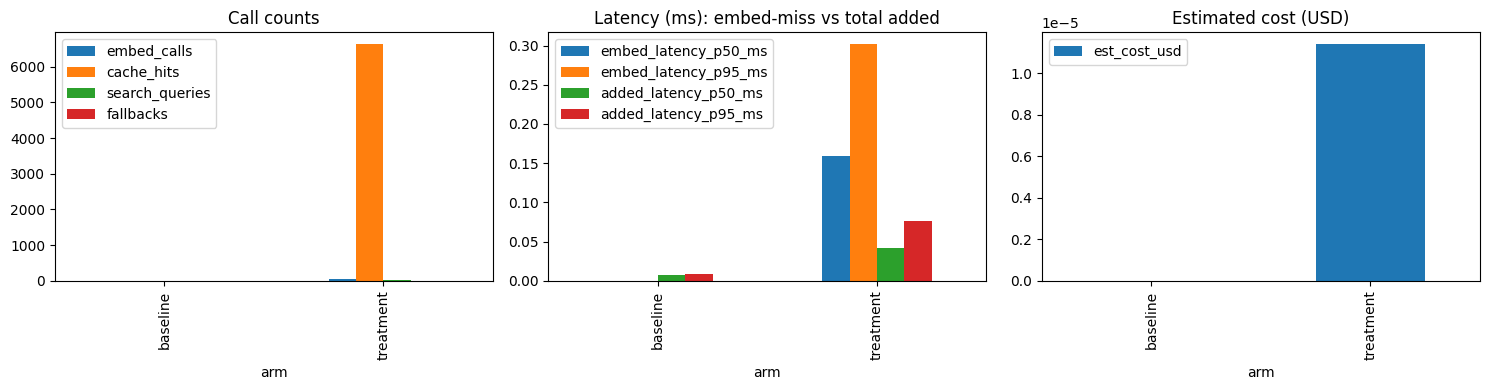

In [7]:
ledger_df = pd.DataFrame([
    dict(arm='baseline', **base.ledger),
    dict(arm='treatment', **treat.ledger),
]).set_index('arm')
display(ledger_df)
fig, ax = plt.subplots(1, 3, figsize=(15, 4))
ledger_df[['embed_calls','cache_hits','search_queries','fallbacks']].plot.bar(ax=ax[0])
ax[0].set_title('Call counts')
ledger_df[['embed_latency_p50_ms','embed_latency_p95_ms',
           'added_latency_p50_ms','added_latency_p95_ms']].plot.bar(ax=ax[1])
ax[1].set_title('Latency (ms): embed-miss vs total added')
ledger_df[['est_cost_usd']].plot.bar(ax=ax[2])
ax[2].set_title('Estimated cost (USD)')
plt.tight_layout(); plt.show()

cross-agent unification fraction: 1.0


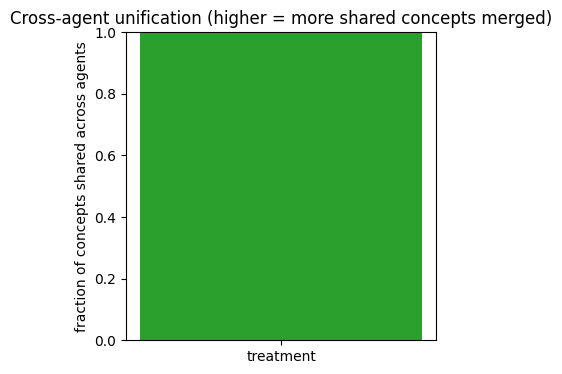

In [8]:
# cross-agent unification (offline metric-only pass) - treatment arms only
emb = kept_embeddings(treat)
if emb is not None:
    kept_log = treat.log[treat.log['kept']][['agent_id','concept_id']].reset_index(drop=True)
    frac = cross_agent_unification(kept_log, emb, tau=(0.55 if AZURE else 0.9))
    print('cross-agent unification fraction:', frac)
    plt.figure(figsize=(4,4))
    plt.bar(['treatment'], [frac], color='tab:green')
    plt.ylim(0, 1); plt.ylabel('fraction of concepts shared across agents')
    plt.title('Cross-agent unification (higher = more shared concepts merged)')
    plt.show()
else:
    print('no embeddings for baseline arm')

In [9]:
if AZURE:
    assert cov_t >= cov_b, (cov_t, cov_b)
    assert med_red_t <= med_red_b, (med_red_t, med_red_b)
    assert ari_t >= 0.5, ari_t
    print('all embedding-variety success criteria passed (LIVE)')
else:
    print('offline run complete (assertions are only enforced on the live Azure arm)')

offline run complete (assertions are only enforced on the live Azure arm)
